In [8]:
import pandas as pd

df = pd.read_csv('vehicles.csv')
print(df.shape)
print(df.head())


(426880, 26)
           id                                                url  \
0  7222695916  https://prescott.craigslist.org/cto/d/prescott...   
1  7218891961  https://fayar.craigslist.org/ctd/d/bentonville...   
2  7221797935  https://keys.craigslist.org/cto/d/summerland-k...   
3  7222270760  https://worcester.craigslist.org/cto/d/west-br...   
4  7210384030  https://greensboro.craigslist.org/cto/d/trinit...   

                   region                         region_url  price  year  \
0                prescott    https://prescott.craigslist.org   6000   NaN   
1            fayetteville       https://fayar.craigslist.org  11900   NaN   
2            florida keys        https://keys.craigslist.org  21000   NaN   
3  worcester / central MA   https://worcester.craigslist.org   1500   NaN   
4              greensboro  https://greensboro.craigslist.org   4900   NaN   

  manufacturer model condition cylinders  ... size  type paint_color  \
0          NaN   NaN       NaN       NaN  .

In [9]:
print(df.columns.tolist())
print(df.isnull().sum())

['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'county', 'state', 'lat', 'long', 'posting_date']
id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64


In [10]:
print(df['price'].describe())
print(df['year'].value_counts().head(10))
print(df['condition'].value_counts())


count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64
year
2017.0    36420
2018.0    36369
2015.0    31538
2013.0    30794
2016.0    30434
2014.0    30283
2019.0    25375
2012.0    23898
2011.0    20341
2020.0    19298
Name: count, dtype: int64
condition
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64


In [11]:
# Keep only useful columns
cols_to_keep = ['price', 'year', 'manufacturer', 'model', 'fuel', 
                'odometer', 'title_status', 'transmission', 
                'drive', 'type', 'paint_color', 'state']

df = df[cols_to_keep]

# Drop rows where the important columns are missing
df = df.dropna(subset=['price', 'year', 'manufacturer', 'odometer', 'fuel', 'transmission'])

# Remove ridiculous prices (under $500 or over $100,000)
df = df[(df['price'] >= 500) & (df['price'] <= 100000)]

# Remove very old or clearly wrong years
df = df[(df['year'] >= 1990) & (df['year'] <= 2024)]

print(df.shape)
print(df.isnull().sum())

(353644, 12)
price                0
year                 0
manufacturer         0
model             3407
fuel                 0
odometer             0
title_status      5890
transmission         0
drive           106133
type             73108
paint_color     101399
state                0
dtype: int64


In [12]:
# Fill remaining missing values
df['model'].fillna('unknown', inplace=True)
df['title_status'].fillna('unknown', inplace=True)
df['drive'].fillna('unknown', inplace=True)
df['type'].fillna('unknown', inplace=True)
df['paint_color'].fillna('unknown', inplace=True)

# Confirm no missing values remain
print(df.isnull().sum())
print(df.shape)


C:\Users\tarin\AppData\Local\Temp\ipykernel_30432\1365323749.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['model'].fillna('unknown', inplace=True)
C:\Users\tarin\AppData\Local\Temp\ipykernel_30432\1365323749.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment usin

price                0
year                 0
manufacturer         0
model             3407
fuel                 0
odometer             0
title_status      5890
transmission         0
drive           106133
type             73108
paint_color     101399
state                0
dtype: int64
(353644, 12)


In [13]:
# Fill remaining missing values
fill_cols = ['model', 'title_status', 'drive', 'type', 'paint_color']
df[fill_cols] = df[fill_cols].fillna('unknown')

# Confirm no missing values remain
print(df.isnull().sum())
print(df.shape)

price           0
year            0
manufacturer    0
model           0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
paint_color     0
state           0
dtype: int64
(353644, 12)


In [14]:
df.to_csv('vehicles_clean.csv', index=False)
print("Saved!")


Saved!


In [1]:
import pandas as pd

df = pd.read_csv('vehicles_clean.csv')
print(df.shape)
print(df.dtypes)


(353644, 12)
price             int64
year            float64
manufacturer        str
model               str
fuel                str
odometer        float64
title_status        str
transmission        str
drive               str
type                str
paint_color         str
state               str
dtype: object


In [2]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['manufacturer', 'model', 'fuel', 'title_status', 
            'transmission', 'drive', 'type', 'paint_color', 'state']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(df.head())

   price    year  manufacturer  model  fuel  odometer  title_status  \
0  33590  2014.0            13  15594     2   57923.0             0   
1  22590  2010.0             7  15941     2   71229.0             0   
2  39590  2020.0             7  15964     2   19160.0             0   
3  30990  2017.0            38  18405     2   41124.0             0   
4  15000  2013.0            12   7835     2  128000.0             0   

   transmission  drive  type  paint_color  state  
0             2      3     8           11      1  
1             2      3     8            1      1  
2             2      3     8            8      1  
3             2      3     8            8      1  
4             0      2    10            0      1  


In [3]:
X = df.drop(columns=['price'])  # everything except price
y = df['price']                 # what we're predicting

print(X.shape, y.shape)

(353644, 11) (353644,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 282915
Testing rows: 70729


In [5]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [6]:
from sklearn.metrics import mean_absolute_error, r2_score

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error: ${mae:,.0f}")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error: $1,818
R² Score: 0.920


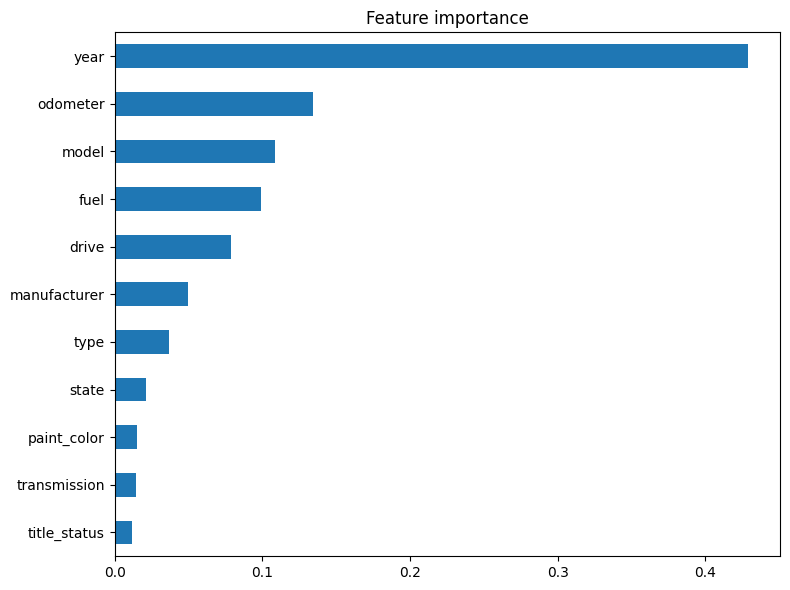

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Feature importance')
plt.tight_layout()
plt.show()

In [8]:
import joblib

joblib.dump(model, 'car_price_model.pkl')
print("Model saved!")

Model saved!
